# 02 · Select equipment and optimize dispatch

Compare grid supply with investment in a 140 kW gas turbine. The optimizer chooses whether to build it and how much power to generate.

Use Python 3.14.2 or newer. In a terminal, run `python -m pip install "OpenUtility[notebook]>=0.1.2"`, then `python -m jupyterlab`. Select that environment's Python kernel and choose **Restart Kernel and Run All Cells**. No repository checkout, external files, credentials, or commercial solver is needed; HiGHS comes with OpenUtility. All data and prices below are synthetic, in arbitrary currency units (CU).

In [1]:
from importlib.metadata import version
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import OpenUtility as ou
from IPython.display import display

print(f"OpenUtility {version('OpenUtility')}")
plt.rcParams.update(
    {"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False}
)
solve = ou.pyomo_utility_system_solver("appsi_highs")

OpenUtility 0.1.2


## Units and assumptions

The turbine consumes gas in kg/s. Its lower heating value is 50,000 kJ/kg and its power slope is 20,000 kJ/kg, giving 40% electrical efficiency. Fuel flow × heating value is kW of fuel input; at 0.04 CU/kWh of fuel, generated electricity costs 0.10 CU/kWh. Capital of 120,000 CU annualizes at 10% to 12,000 CU/year. There is no maintenance, minimum load, export, or exhaust heat recovery. These simplified coefficients illustrate the API; they are not a turbine specification.

In [2]:
# The current schema requires a steam level, even for electricity/HPR examples.
# This zero-duty placeholder contributes no heat, steam, or cost.
level = ou.SteamLevelCandidate(
    name="MP_100",
    steam_main="MP",
    temperature=100.0,
    source_heat_available=0.0,
    sink_heat_demand=0.0,
    generation_enthalpy_delta=1.0,
    use_enthalpy_delta=1.0,
)


def electricity_case(demand=100.0, tariff=0.20):
    return ou.UtilitySystemModelData(
        steam_mains=("MP",),
        steam_levels=(level,),
        power_demand=demand,
        operating_hours=4000.0,
        grid_import_limit=200.0,
        grid_export_limit=0.0,
        electricity_cost=ou.ElectricityCost(import_unit_cost=tariff),
        gas_turbines=(
            ou.GasTurbineCandidate(
                name="GT",
                fuel_lhv=50000.0,
                power_slope=20000.0,
                power_intercept=0.0,
                min_fuel_flow=0.0,
                max_fuel_flow=0.007,
                minimum_load_fraction=0.0,
            ),
        ),
        fuel_costs=(
            ou.FuelCost(
                name="gas",
                equipment_type="gas_turbine",
                equipment_name="GT",
                unit_cost=0.04,
            ),
        ),
        equipment_costs=(
            ou.EquipmentCost(
                name="GT investment",
                equipment_type="gas_turbine",
                equipment_name="GT",
                annualization_factor=0.1,
                installation_factor=1.0,
                variable_capital_cost=0.0,
                fixed_capital_cost=120000.0,
            ),
        ),
    )


data = electricity_case()
model = ou.build_utility_system_model(data)
status = solve(model)
assert status.termination_condition == "optimal", status

## Compare annual costs

Grid alone costs 80,000 CU/year. The turbine costs 40,000 CU/year in fuel plus 12,000 CU/year in capital, so it should supply the entire 100 kW load.

,Fuel,Electricity,Annualized capital,Total
Grid only,0.0,80000.0,0.0,80000.0
Optimal system,40000.0,0.0,12000.0,52000.0


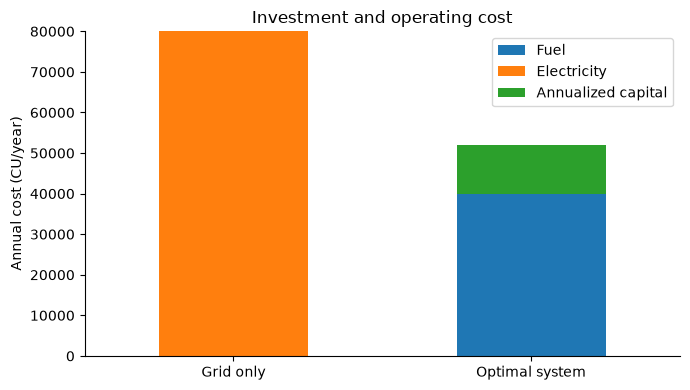

In [3]:
assert pyo.value(model.gas_turbine_selected["GT"]) > 0.5
assert math.isclose(
    pyo.value(model.gas_turbine_power_generation["GT"]), 100.0, abs_tol=1e-6
)
assert math.isclose(pyo.value(model.total_annualized_cost), 52000.0, abs_tol=1e-6)
costs = pd.DataFrame(
    {
        "Grid only": {"Fuel": 0.0, "Electricity": 80000.0, "Annualized capital": 0.0},
        "Optimal system": {
            "Fuel": pyo.value(model.total_fuel_operating_cost),
            "Electricity": pyo.value(model.electricity_operating_cost),
            "Annualized capital": pyo.value(model.total_annualized_capital_cost),
        },
    }
).T
display(costs.assign(Total=costs.sum(axis=1)))
ax = costs.plot.bar(stacked=True, rot=0)
ax.set(ylabel="Annual cost (CU/year)", title="Investment and operating cost")
plt.tight_layout()
plt.show()

## Try it

Reduce the electricity tariff to 0.12 CU/kWh. Predict whether 8,000 CU/year in fuel savings justify 12,000 CU/year in capital. Notebook 03 explores this tradeoff across many cases.